<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_2/blob/main/PRACTICE_Black_Friday_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning: Linear Regression

## Black Friday Sales Prediction:

We are going to use a dataset of product purchases during a Black Friday (in the US). The main idea is to be able to generate a predictor that allows us to predict the `purchase amount`.

In order to achieve a good predictor we must apply the different concepts that we have been learning:

* `Exploration`
* `Feature Engineering`
* `Modeling`
* `Evaluation`

The dataset here is a sample of the transactions made in a retail store. The store wants to know better the customer `purchase` behaviour against different products. The problem is a `regression problem` where we are trying to predict the dependent variable (the amount of purchase) with the help of the information contained in the other variables.

### You can try differents Scikit-Learn models from [Linear Models](https://scikit-learn.org/1.5/modules/linear_model.html)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

!gdown "1HZ_nk9Q0xp-qbAtXZvDxK5VNVfavt7ph"

data = pd.read_csv("BlackFriday.csv")
data.sample(5)

Downloading...
From: https://drive.google.com/uc?id=1HZ_nk9Q0xp-qbAtXZvDxK5VNVfavt7ph
To: /content/BlackFriday.csv
100% 25.0M/25.0M [00:00<00:00, 34.1MB/s]


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
244206,1001632,P00109542,M,26-35,16,B,1,0,8,14.0,17.0,5960
58067,1002962,P00087342,M,36-45,3,A,2,0,5,14.0,16.0,5204
189384,1005256,P00135742,M,26-35,16,B,4+,1,6,8.0,NaN,16469
174637,1003029,P0096542,M,18-25,4,A,4+,0,3,4.0,12.0,13324
247792,1002116,P0098242,M,18-25,4,B,4+,1,1,16.0,NaN,12087


In [3]:
print("Shape:", data.shape)
display(data.head())
print("\nInfo:")
display(data.info())
print("\nDescripción numérica:")
display(data.describe())
print("\nValores nulos por columna:")
display(data.isna().sum())

Shape: (537577, 12)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


None


Descripción numérica:


,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.375770e+05,537577.00000,537577.000000,537577.000000,370591.000000,164278.000000,537577.000000
mean,1.002992e+06,8.08271,0.408797,5.295546,9.842144,12.669840,9333.859853
std,1.714393e+03,6.52412,0.491612,3.750701,5.087259,4.124341,4981.022133
min,1.000001e+06,0.00000,0.000000,1.000000,2.000000,3.000000,185.000000
25%,1.001495e+06,2.00000,0.000000,1.000000,5.000000,9.000000,5866.000000
50%,1.003031e+06,7.00000,0.000000,5.000000,9.000000,14.000000,8062.000000
75%,1.004417e+06,14.00000,1.000000,8.000000,15.000000,16.000000,12073.000000
max,1.006040e+06,20.00000,1.000000,18.000000,18.000000,18.000000,23961.000000



Valores nulos por columna:


,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,166986


--- Gender ---


,count
Gender,
M,405380
F,132197


--- Age ---


,count
Age,
26-35,214690
36-45,107499
18-25,97634
46-50,44526
51-55,37618
55+,20903
0-17,14707


--- City_Category ---


,count
City_Category,
B,226493
C,166446
A,144638


--- Stay_In_Current_City_Years ---


,count
Stay_In_Current_City_Years,
1,189192
2,99459
3,93312
4+,82889
0,72725


--- Marital_Status ---


,count
Marital_Status,
0,317817
1,219760


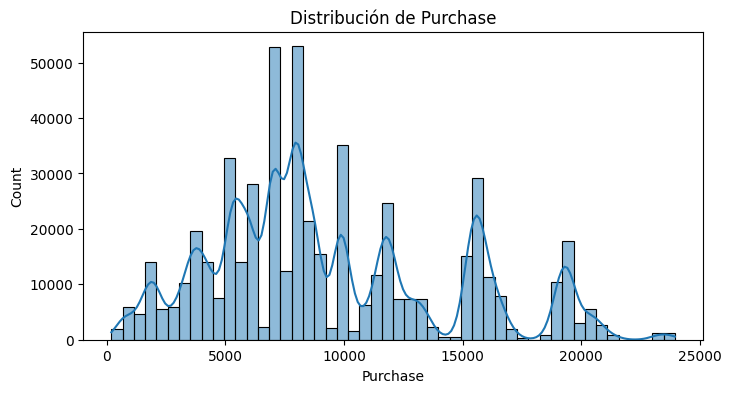

In [4]:
for col in ["Gender", "Age", "City_Category", "Stay_In_Current_City_Years", "Marital_Status"]:
    print(f"--- {col} ---")
    display(data[col].value_counts(dropna=False))

# Distribución del target Purchase
plt.figure(figsize=(8,4))
sns.histplot(data["Purchase"], bins=50, kde=True)
plt.title("Distribución de Purchase")
plt.show()

In [5]:
df = data.copy()

for col in ["Product_Category_2", "Product_Category_3"]:
    df[col + "_missing"] = df[col].isna().astype(int)
    df[col] = df[col].fillna(0)

age_map = {"0-17":0, "18-25":1, "26-35":2, "36-45":3, "46-50":4, "51-55":5, "55+":6}
df["Age_encoded"] = df["Age"].map(age_map)

df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].replace("4+", "4").astype(int)

df["Gender_enc"] = (df["Gender"] == "M").astype(int)

df[["Product_Category_1","Product_Category_2","Product_Category_3"]] = df[["Product_Category_1","Product_Category_2","Product_Category_3"]].astype(int)

print("Después de transformaciones:")
display(df.head())

Después de transformaciones:


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Product_Category_2_missing,Product_Category_3_missing,Age_encoded,Gender_enc
0,1000001,P00069042,F,0-17,10,A,2,0,3,0,0,8370,1,1,0,0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6,14,15200,0,0,0,0
2,1000001,P00087842,F,0-17,10,A,2,0,12,0,0,1422,1,1,0,0
3,1000001,P00085442,F,0-17,10,A,2,0,12,14,0,1057,0,1,0,0
4,1000002,P00285442,M,55+,16,C,4,0,8,0,0,7969,1,1,6,1


In [6]:
features = [
    "Gender_enc",
    "Age_encoded",
    "Stay_In_Current_City_Years",
    "Marital_Status",
    "Occupation",
    "City_Category",
    "Product_Category_1","Product_Category_2","Product_Category_3",
    "Product_Category_2_missing", "Product_Category_3_missing"
]

X = df[features].copy()
y = df["Purchase"].copy()

X = pd.get_dummies(X, columns=["City_Category"], drop_first=True)

print("Features finales:", X.columns.tolist())
print("Shape X, y:", X.shape, y.shape)

Features finales: ['Gender_enc', 'Age_encoded', 'Stay_In_Current_City_Years', 'Marital_Status', 'Occupation', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Product_Category_2_missing', 'Product_Category_3_missing', 'City_Category_B', 'City_Category_C']
Shape X, y: (537577, 12) (537577,)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = ["Age_encoded", "Stay_In_Current_City_Years", "Product_Category_1","Product_Category_2","Product_Category_3"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE (LinearRegression baseline): {rmse:.2f}")
print(f"R^2: {r2:.4f}")

RMSE (LinearRegression baseline): 4619.48
R^2: 0.1407


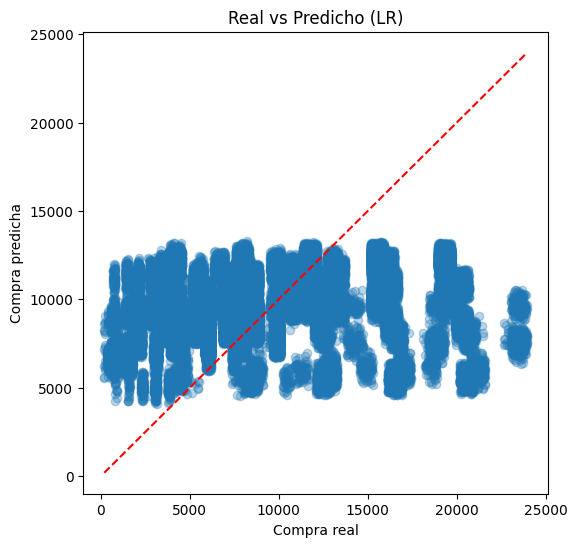

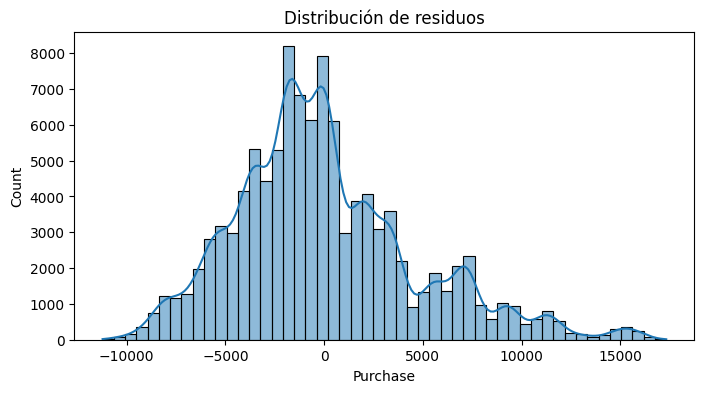

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Compra real")
plt.ylabel("Compra predicha")
plt.title("Real vs Predicho (LR)")
plt.show()

resid = y_test - y_pred
plt.figure(figsize=(8,4))
sns.histplot(resid, bins=50, kde=True)
plt.title("Distribución de residuos")
plt.show()

In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

ridge = Ridge(alpha=1.0)
scores = -cross_val_score(ridge, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
print("CV RMSE (Ridge, alpha=1.0):", scores.mean(), "±", scores.std())

CV RMSE (Ridge, alpha=1.0): 4613.773587607566 ± 7.726920234073332
